In [1]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

In [2]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"


In [4]:

fnames={}

case_id = "FACE_1PFT_AllomBl_r240326_AgBgW_daily"
case_id = "FACE_1PFT_r240701_dL2FR_p0.2" # density 0.2 #/m2
sites= ("US-ORN", "US-DUK")
#sites= ("US-ORN",)#, "US-DUK")

#run_case = "trans"
run_case = "trans"
#run_case = "aCO2"
#run_case = "eCO2"

for site in sites:
    # COnly
    fnames[f"{case_id}_{site}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
    # RD
    fn = ['RD','ECA']
    for f in fn:
        fnames[f"{case_id}_{site}_{f}_{run_case}"] = f"{path_in}{case_id}_{f}_processed/{case_id}_{f}_{site}_{run_case}.nc"
    #if site == "US-ORN":
    #    fnames[f"{case_id}_{site}_spins"] = f"{path_in}{case_id}_processed/concatenated_Bharat_H_1PFTallom_r240228_AgBgW_spins_daily_US-ORN_I1850ELMFATES_ad_spinup.nc"
    


In [5]:
 fnames

{'FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_COnly_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240701_dL2FR_p0.2_processed/FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_trans.nc',
 'FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240701_dL2FR_p0.2_RD_processed/FACE_1PFT_r240701_dL2FR_p0.2_RD_US-ORN_trans.nc',
 'FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_ECA_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240701_dL2FR_p0.2_ECA_processed/FACE_1PFT_r240701_dL2FR_p0.2_ECA_US-ORN_trans.nc',
 'FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_COnly_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240701_dL2FR_p0.2_processed/FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_trans.nc',
 'FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_RD_trans': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r240701_dL2FR_p0.2_RD_processed/FACE_1PFT_r240701_dL2FR_p0.2_RD_US-DUK_trans.nc',
 'FACE_1

In [6]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key)
    #ds[key] = xr.open_mfdataset(fnames[key],decode_times=True)
    ds[key] = xr.open_mfdataset(fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key], decode_times=False) # inorder to read the "FATES_DAYSINCE_COLDLEAFOFF". because days are interpreted differeny by xarry
    
    
#for idx, key in enumerate(ds.keys()):
#    ds[key]['time'] =  pd.to_datetime(ds[key].time.values.astype(str))

FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_COnly_trans
FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_RD_trans
FACE_1PFT_r240701_dL2FR_p0.2_US-ORN_ECA_trans
FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_COnly_trans
FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_RD_trans
FACE_1PFT_r240701_dL2FR_p0.2_US-DUK_ECA_trans


In [7]:
# How long do you want the simulation plots?
max_r_years = 31# -1# 40
max_r_years = 12 # FACE exp

In [8]:
"-".join(key.split("_")[6:])

'ECA-trans'

transpiration beta factor
transpiration beta factor
transpiration beta factor
transpiration beta factor
transpiration beta factor
transpiration beta factor


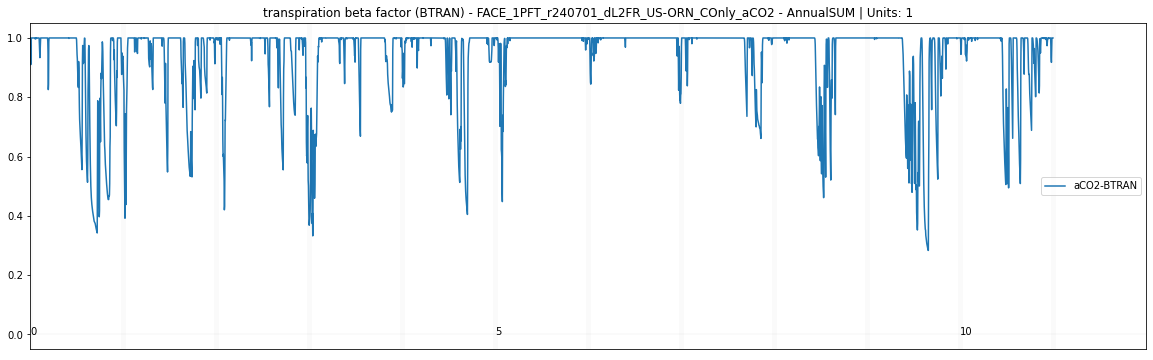

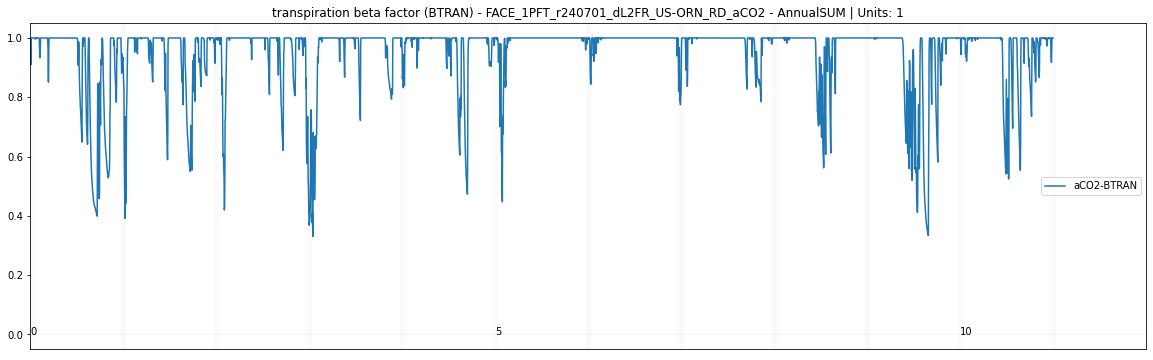

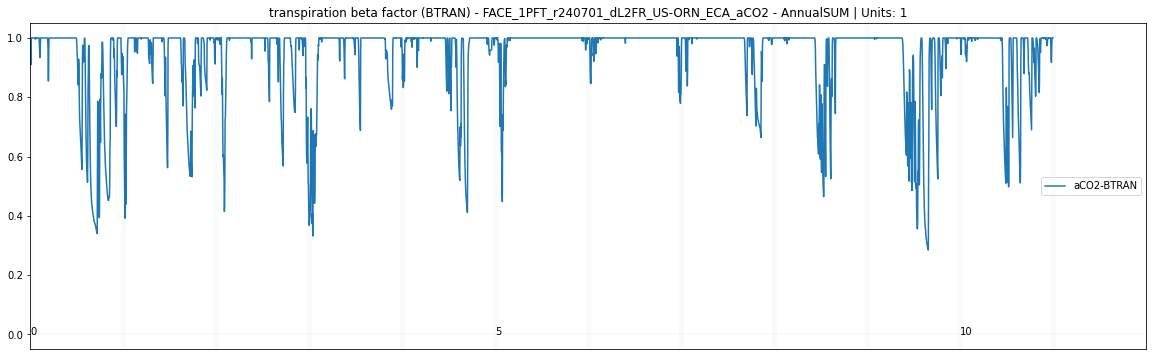

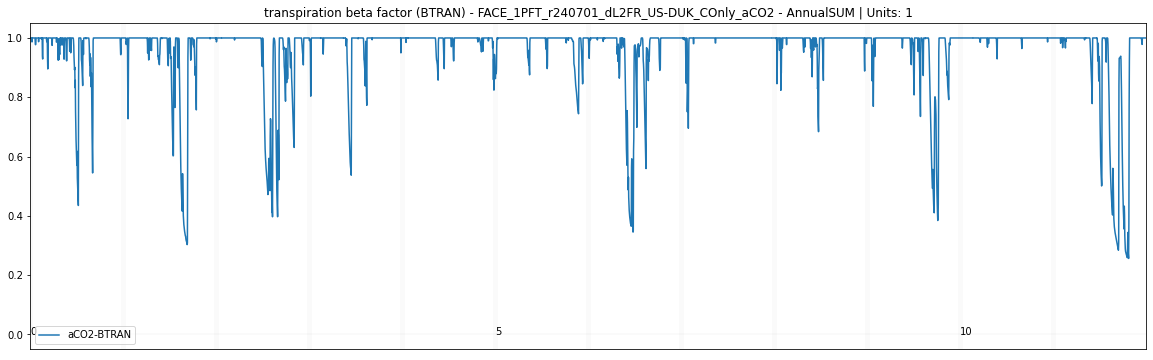

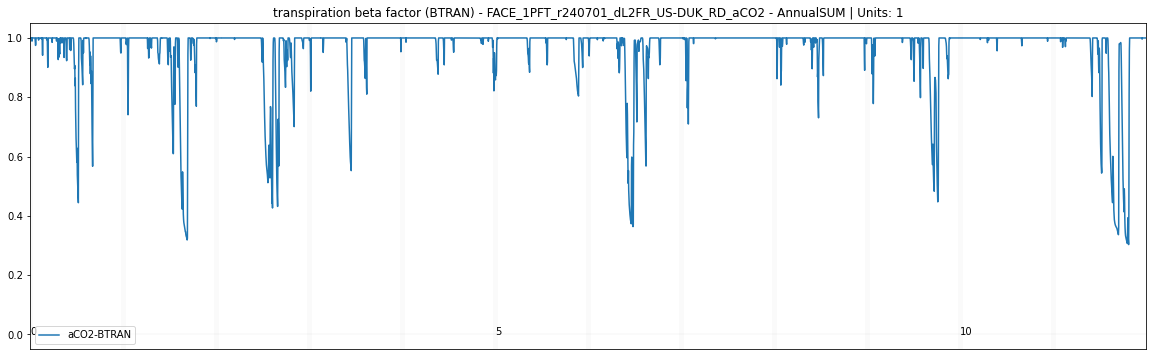

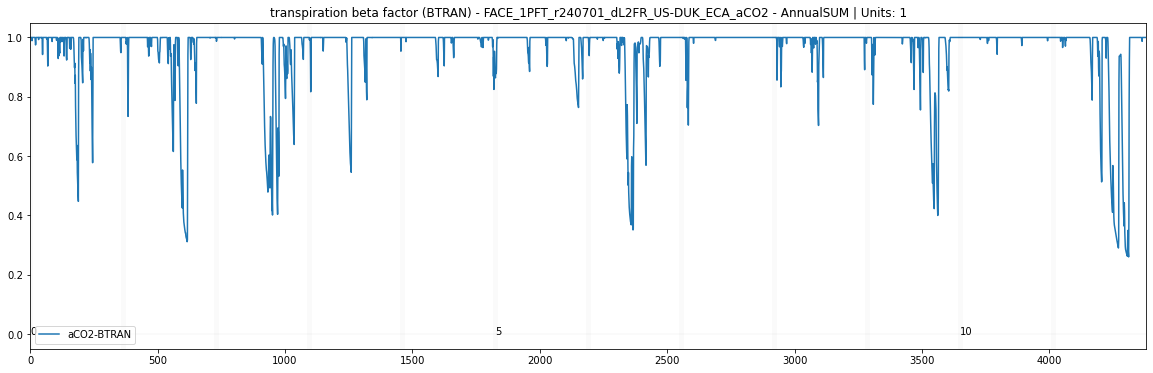

In [35]:

vars = (
        "BTRAN",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

total projected leaf area index
total projected leaf area index
total projected leaf area index
total projected leaf area index
total projected leaf area index
total projected leaf area index


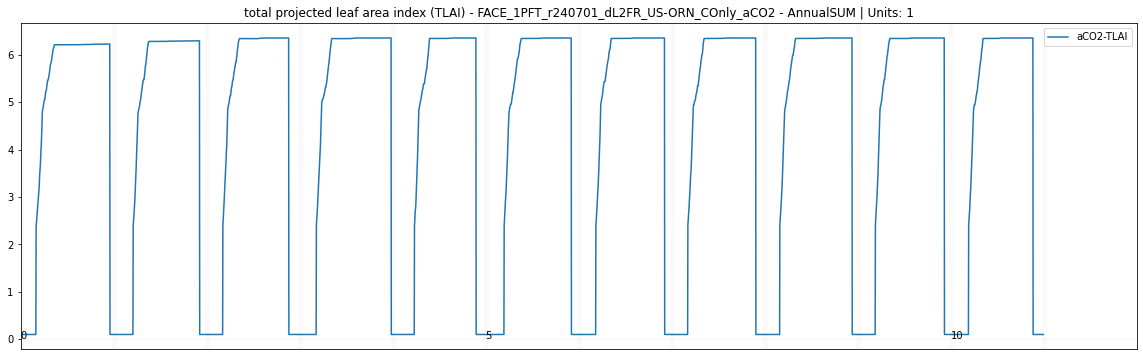

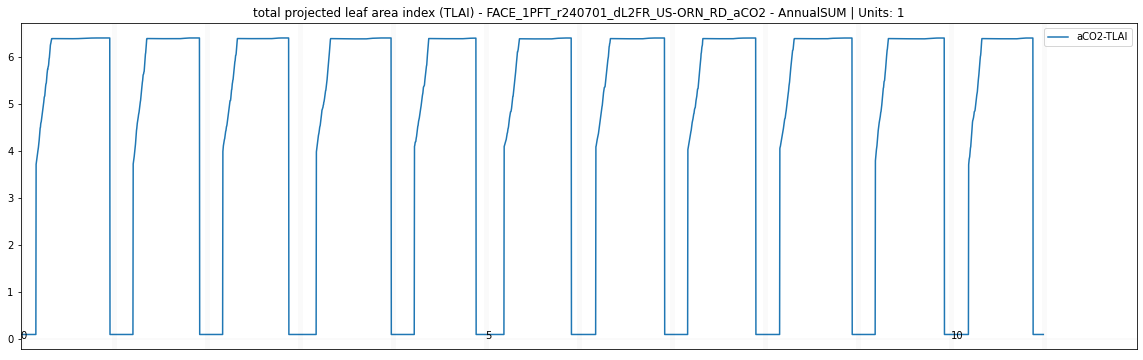

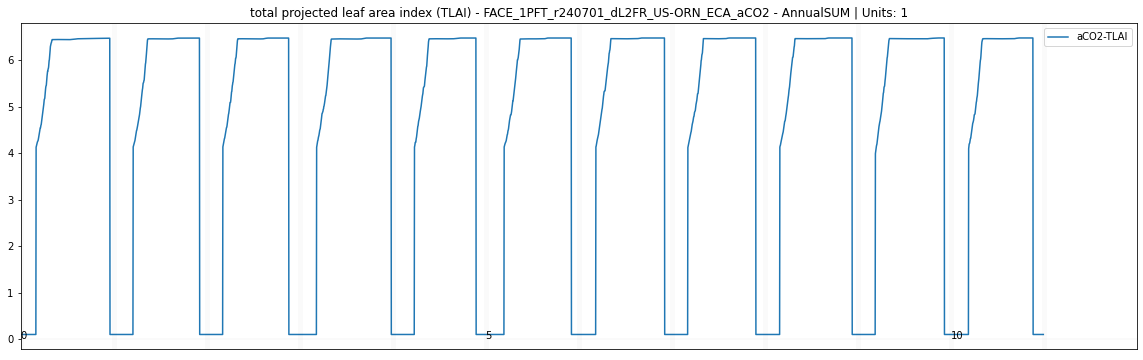

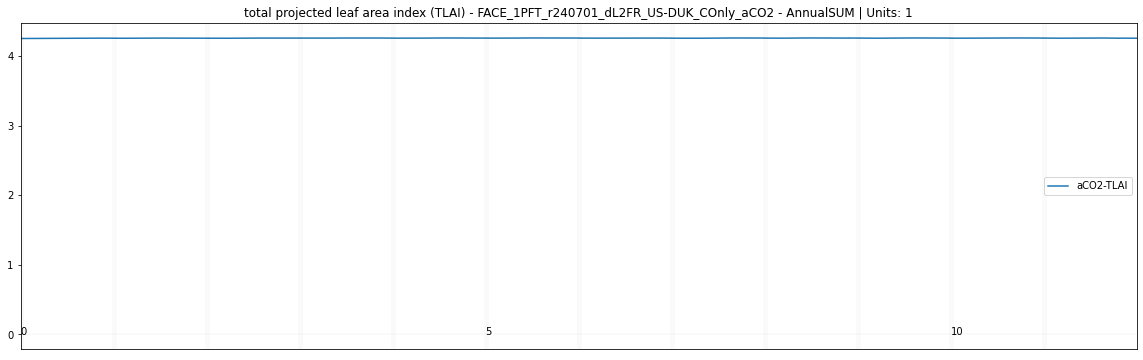

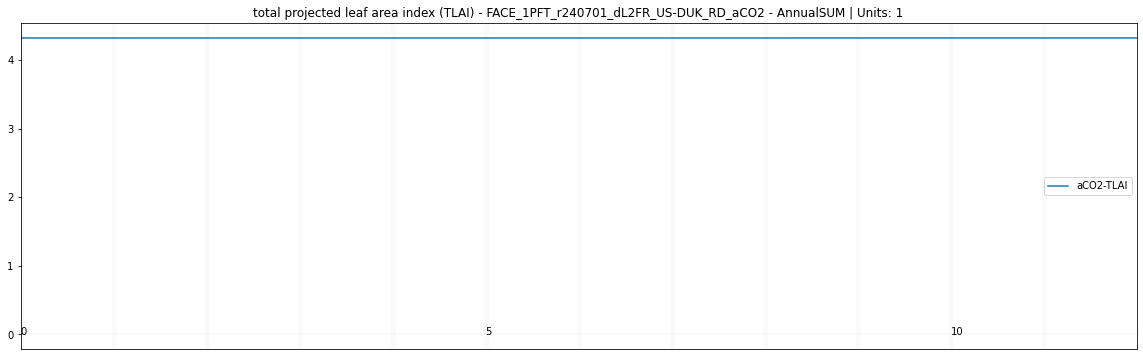

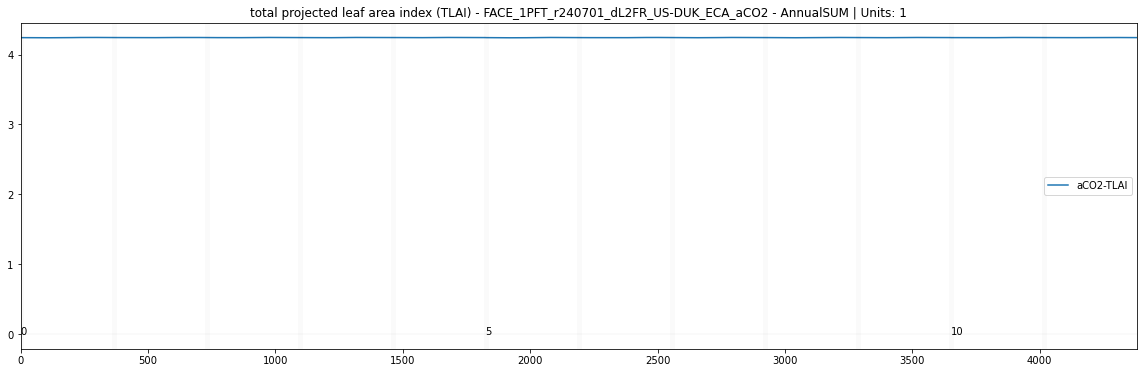

In [36]:

vars = (
        "TLAI",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second
gross primary production in kg carbon per m2 per second
net primary production in kg carbon per m2 per second
autotrophic respiration in kg carbon per m2 per second


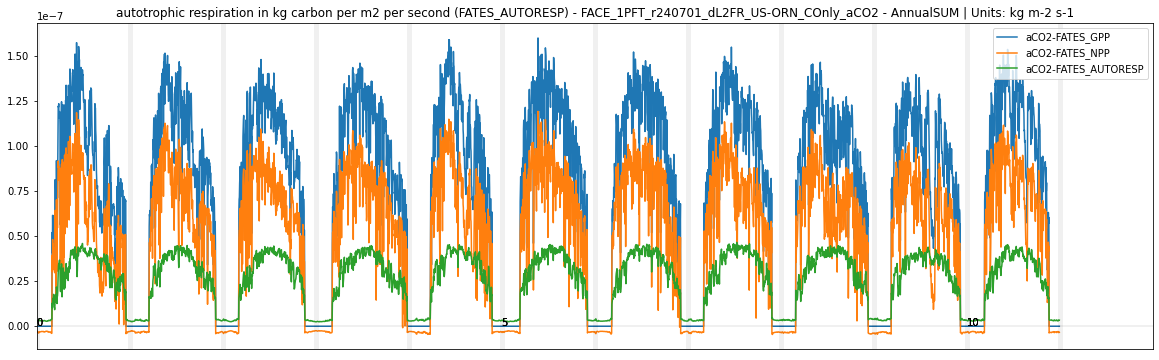

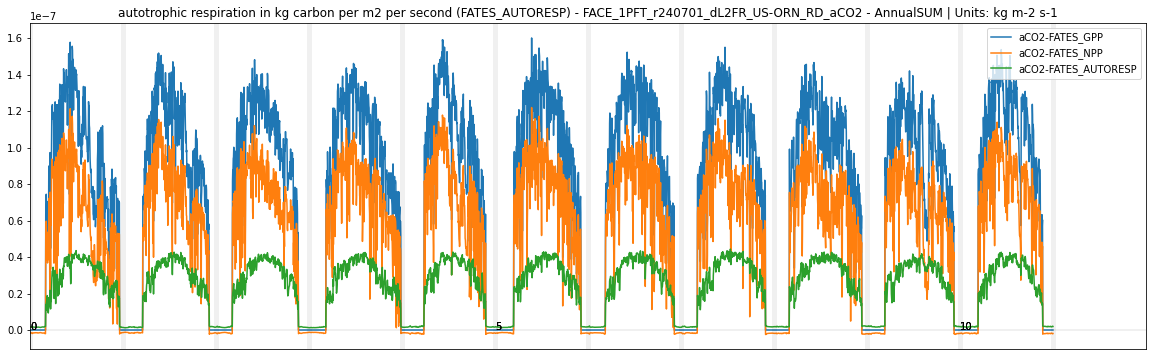

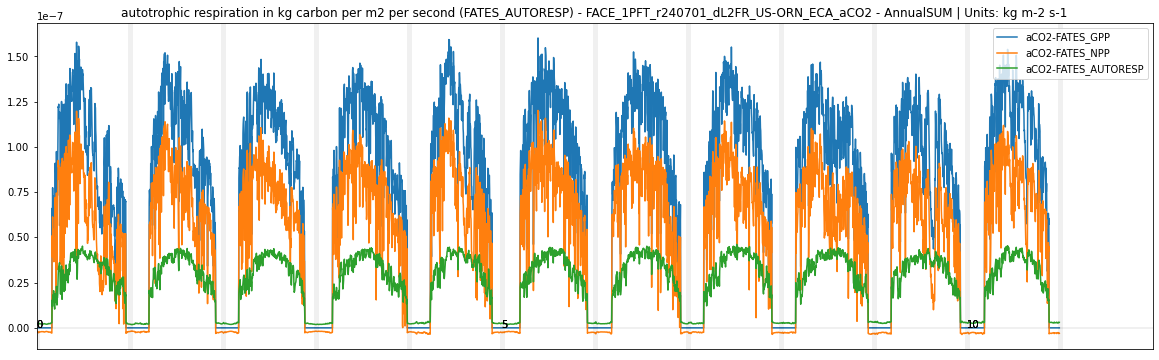

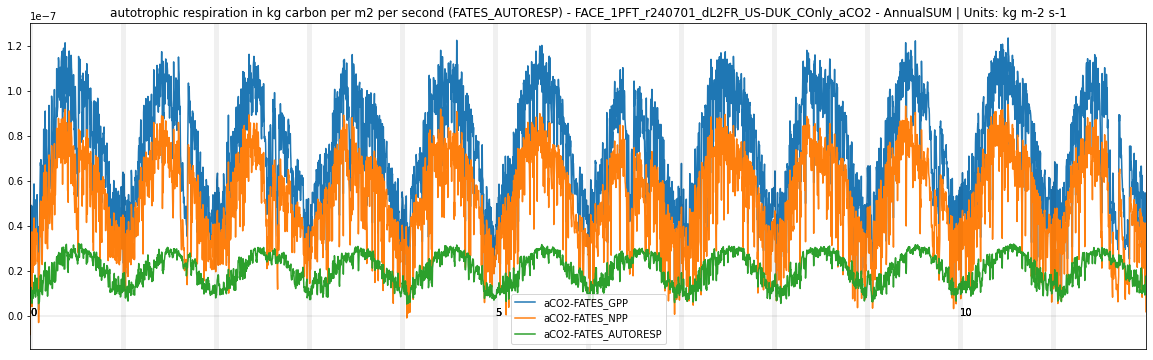

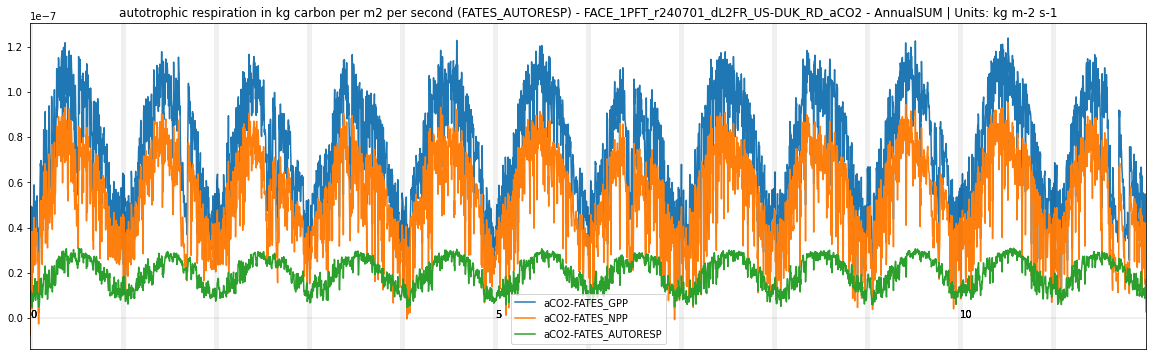

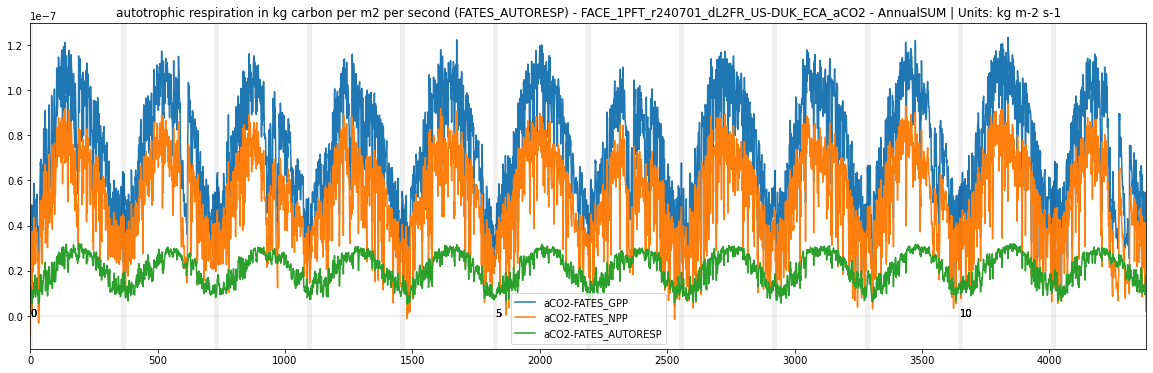

In [37]:
vars = ("FATES_GPP",
        "FATES_NPP",
        "FATES_AUTORESP",
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [38]:
ds.keys()

dict_keys(['FACE_1PFT_r240701_dL2FR_US-ORN_COnly_aCO2', 'FACE_1PFT_r240701_dL2FR_US-ORN_RD_aCO2', 'FACE_1PFT_r240701_dL2FR_US-ORN_ECA_aCO2', 'FACE_1PFT_r240701_dL2FR_US-DUK_COnly_aCO2', 'FACE_1PFT_r240701_dL2FR_US-DUK_RD_aCO2', 'FACE_1PFT_r240701_dL2FR_US-DUK_ECA_aCO2'])

total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant fine roots in kg carbon per m2


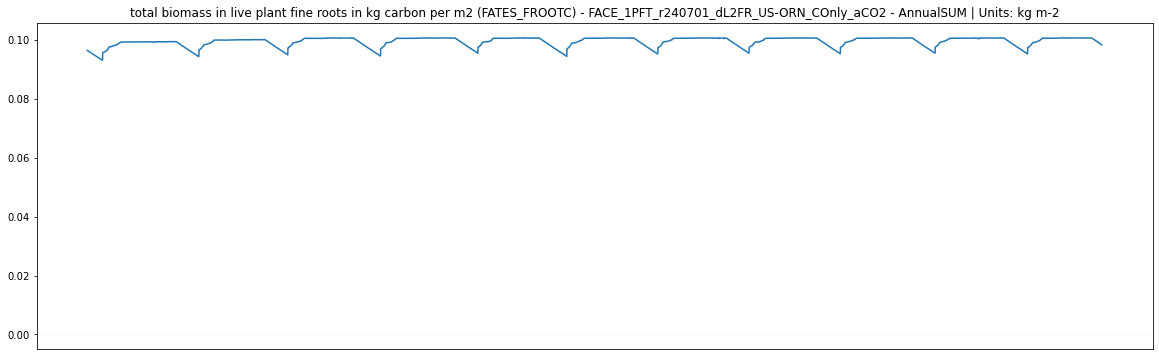

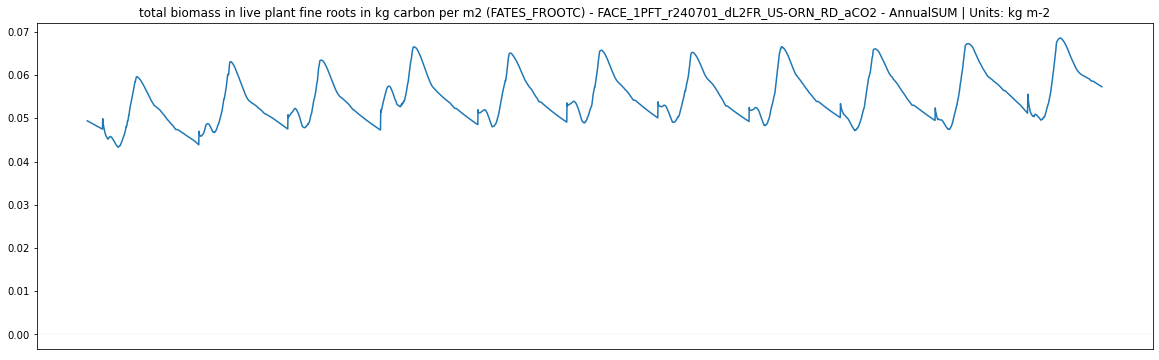

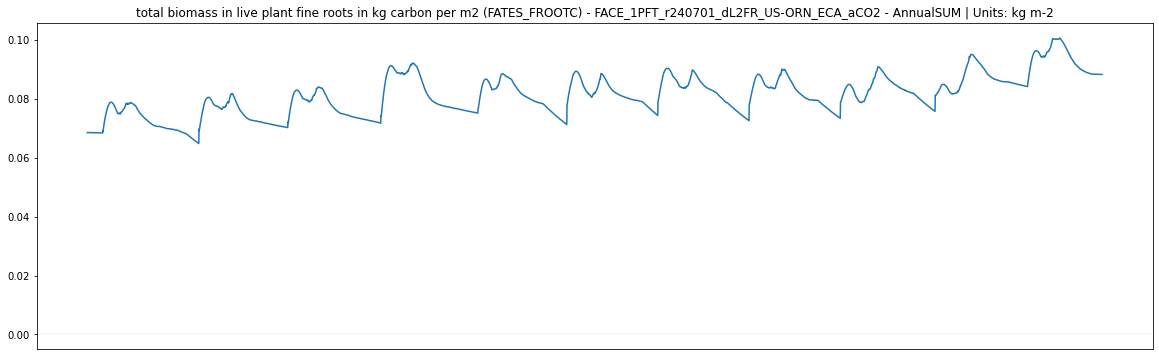

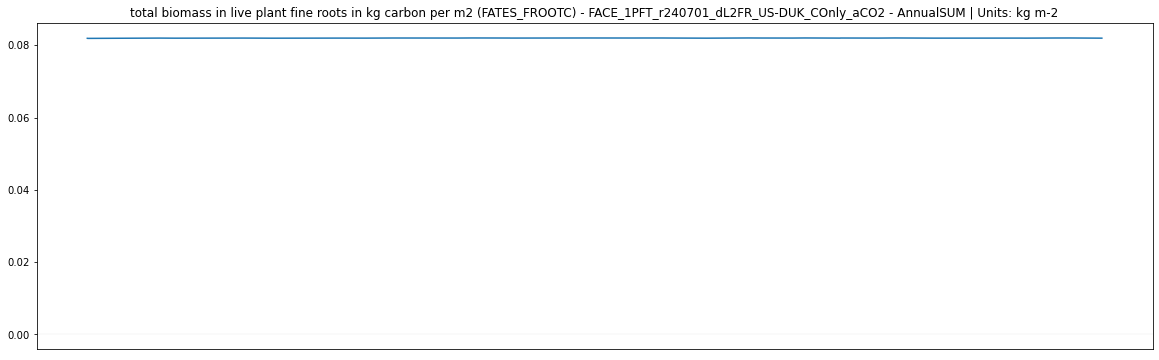

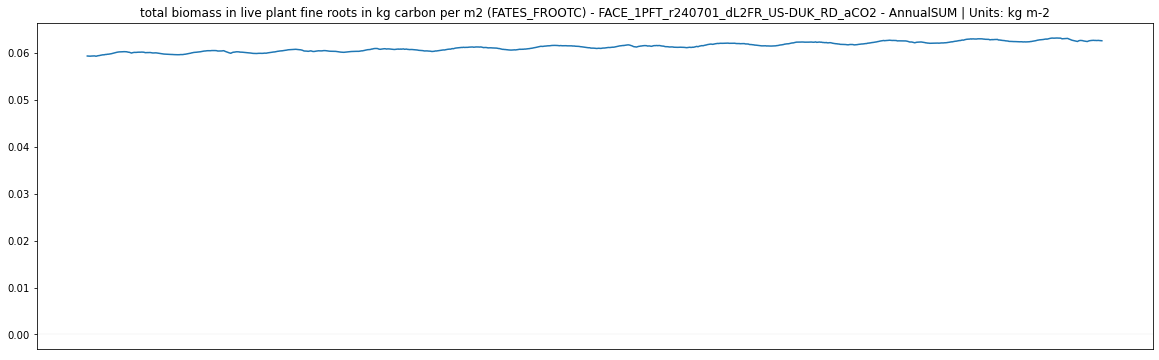

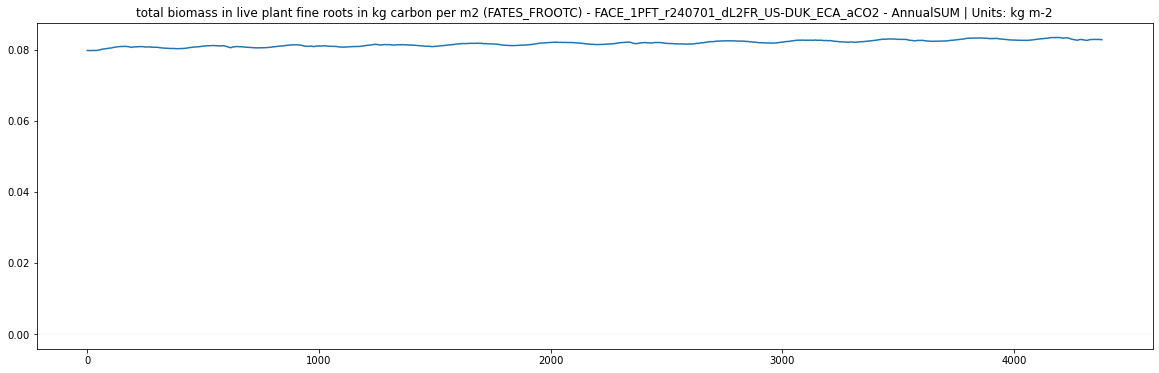

In [39]:
vars = (
            "FATES_FROOTC",
        #"FATES_LEAFC",
        #"FATES_STOREC",
    #"FATES_SAPWOODC",
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            dict_vars_data[var][site][subset.index[0]].units
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2
total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2
total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2
total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2
total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg carbon per m2
total biomass in live plant storage in kg carbon per m2 land area
total biomass in live plant fine roots in kg carbon per m2
total biomass in live plant leaves in kg 

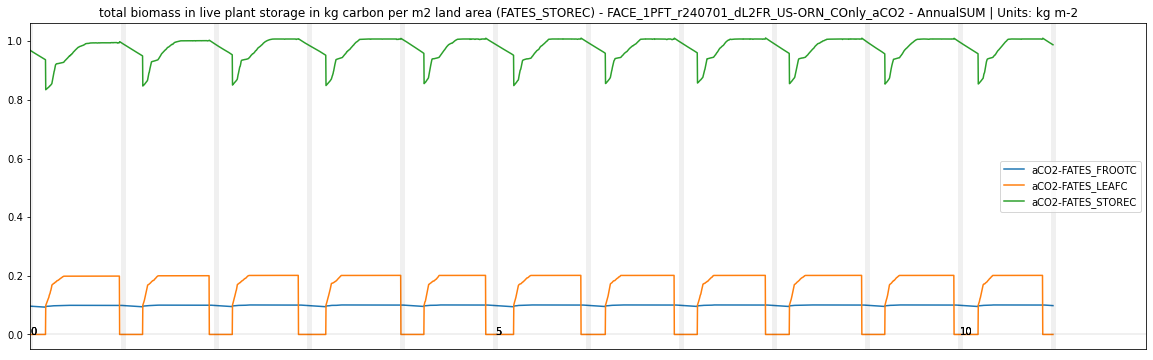

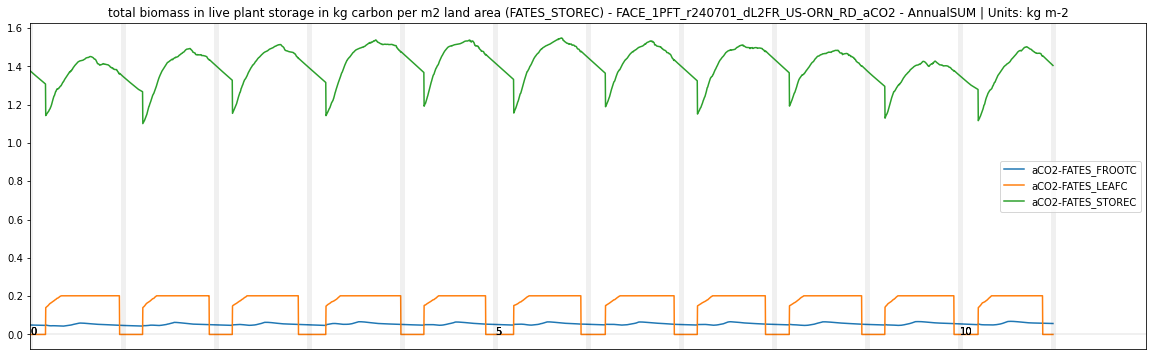

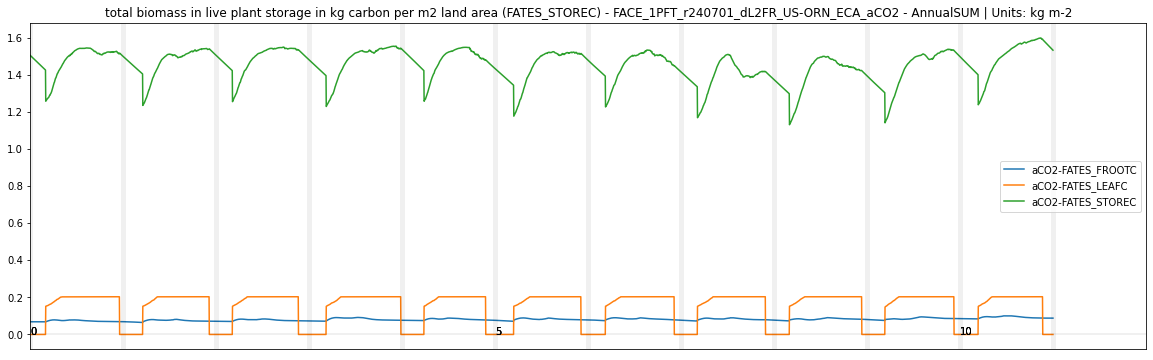

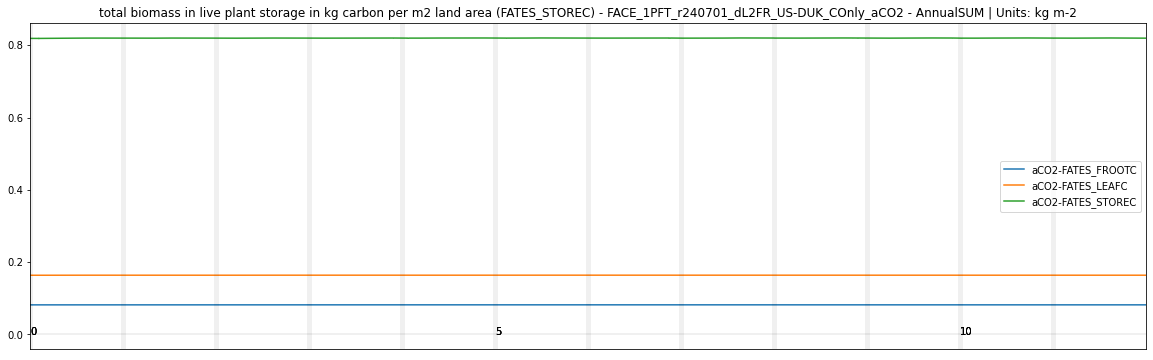

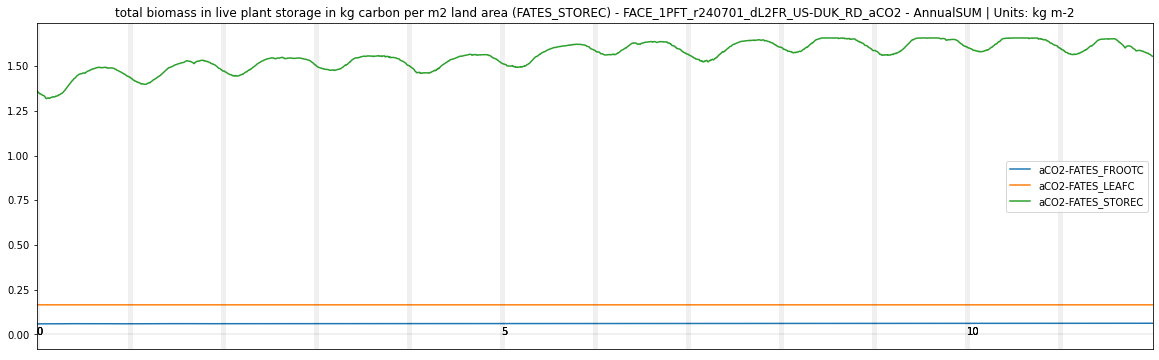

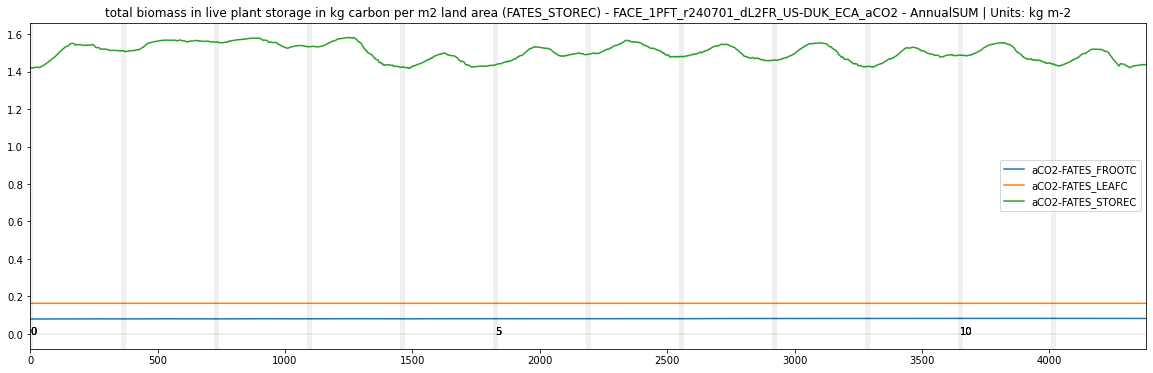

In [40]:
vars = (
            "FATES_FROOTC",
        "FATES_LEAFC",
        "FATES_STOREC",
    #"FATES_SAPWOODC",
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-ORN_COnly_aCO2
net rate of N mineralization
net rate of N mineralization
ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-DUK_COnly_aCO2
net rate of N mineralization
net rate of N mineralization


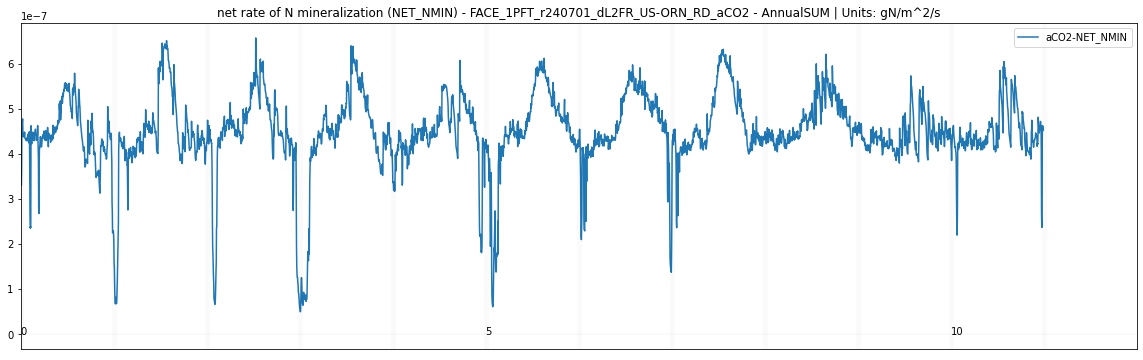

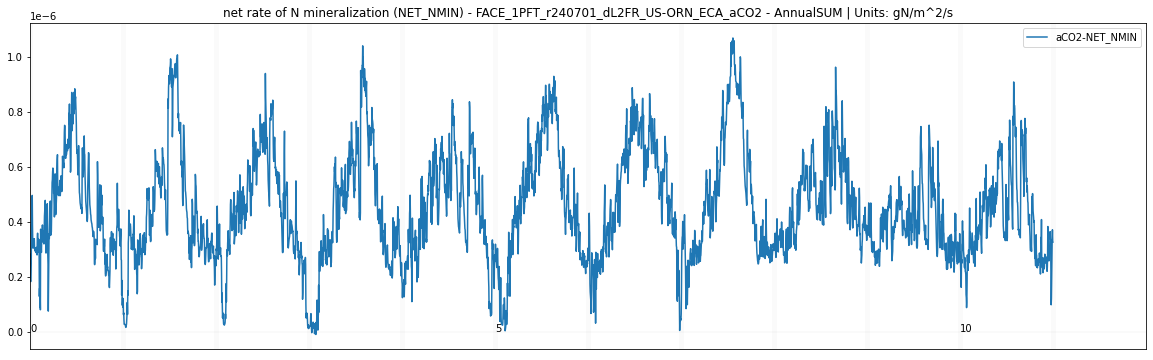

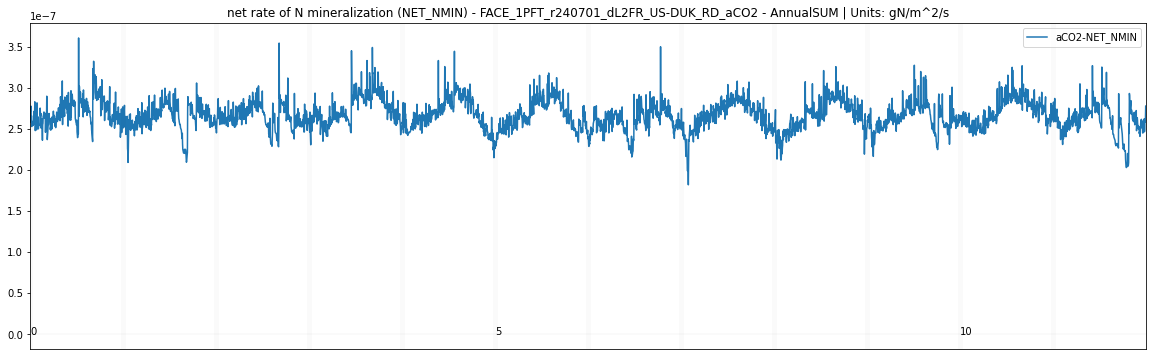

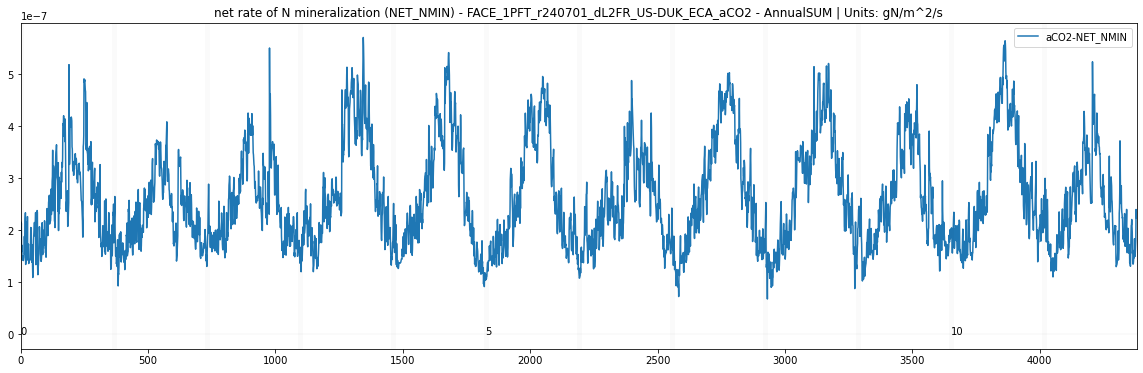

In [41]:

vars = (
        "NET_NMIN",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-ORN_COnly_aCO2
key FACE_1PFT_r240701_dL2FR_US-ORN_RD_aCO2
Storage C fraction of target
key FACE_1PFT_r240701_dL2FR_US-ORN_RD_aCO2
storage N fraction of target
key FACE_1PFT_r240701_dL2FR_US-ORN_ECA_aCO2
Storage C fraction of target
key FACE_1PFT_r240701_dL2FR_US-ORN_ECA_aCO2
storage N fraction of target
ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-DUK_COnly_aCO2
key FACE_1PFT_r240701_dL2FR_US-DUK_RD_aCO2
Storage C fraction of target
key FACE_1PFT_r240701_dL2FR_US-DUK_RD_aCO2
storage N fraction of target
key FACE_1PFT_r240701_dL2FR_US-DUK_ECA_aCO2
Storage C fraction of target
key FACE_1PFT_r240701_dL2FR_US-DUK_ECA_aCO2
storage N fraction of target


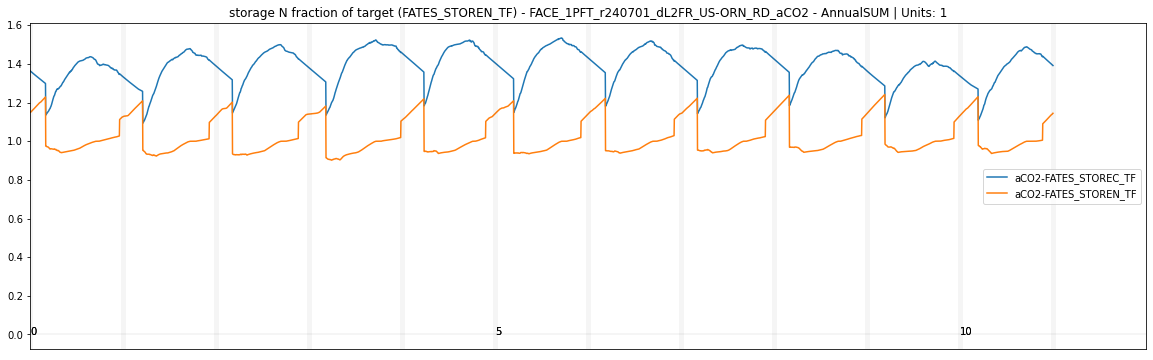

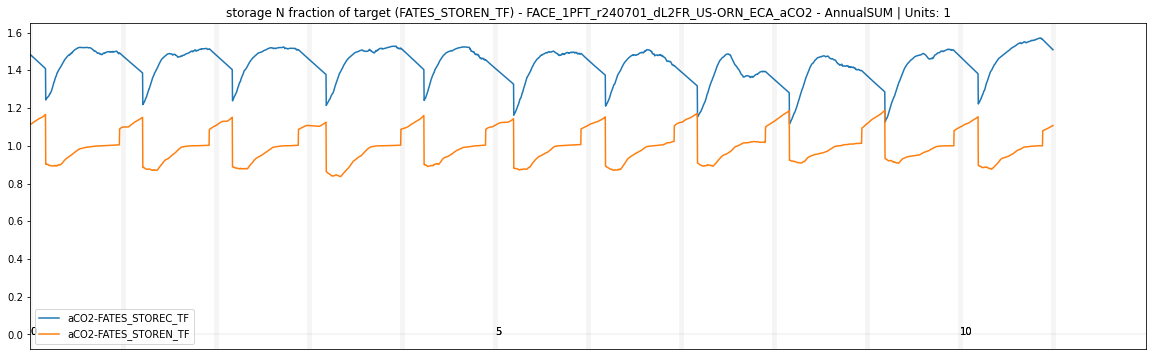

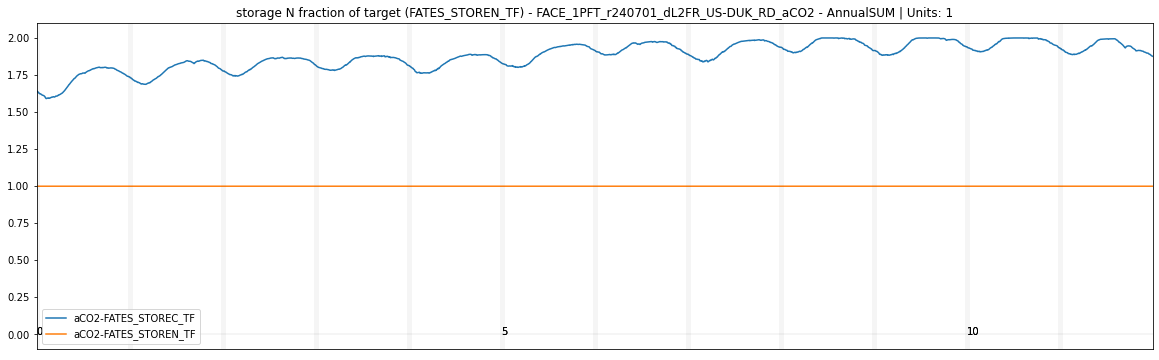

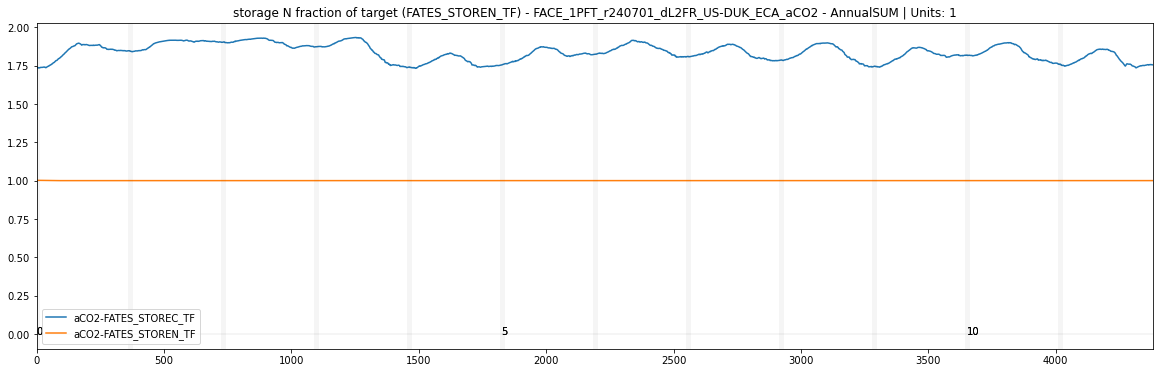

In [42]:

vars = (
        "FATES_STOREC_TF",
        "FATES_STOREN_TF"
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            print ("key",key)
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            plt.grid()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [43]:
#FACE_1PFT_AllomBl_r240326_AgBgW_daily_US-ORN_RD_spins
#FACE_1PFT_AllomBl_r240326_AgBgW_daily_US-ORN_ECA_spins

for key in ["FACE_1PFT_AllomBl_r240326_AgBgW_daily_US-ORN_RD_spins", "FACE_1PFT_AllomBl_r240326_AgBgW_daily_US-ORN_ECA_spins"]:
    plt.figure(figsize=(20,6))
    plt.plot(ds[key]["FATES_STOREC_TF"]/ds[key]["FATES_STOREN_TF"], label = f'{"-".join(key.split("_")[6:])}-FATES_STOREC_TF/FATES_STOREN_TF')
    plt.title(f"FATES_STOREC_TF/FATES_STOREN_TF {key}")
    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
    if idx != len(ds.keys())-1 : 
        plt.xticks([])
        plt.xlabel(None)
    plt.legend()
    plt.grid()
    if max_r_years > 0:
        plt.xlim(0,max_r_years*365)
    for i in range(max_r_years):
        plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
        if i%5==0:
            plt.text(i*365,0, int(i))
    plt.show()

KeyError: 'FACE_1PFT_AllomBl_r240326_AgBgW_daily_US-ORN_RD_spins'

<Figure size 1440x432 with 0 Axes>

In [ ]:

vars = (
        "FATES_STOREC_TF",
       #"FATES_STOREN_TF"
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key]["FATES_STOREC_TF"]/ds[key]["FATES_STOREN_TF"], label = f'{"-".join(key.split("_")[6:])}-FATES_STOREC_TF/FATES_STOREN_TF')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            plt.grid()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [ ]:

vars = (
        "FATES_L2FR",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            plt.grid()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [ ]:

vars = (
        "ACTUAL_IMMOB",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [ ]:

vars = (
        "F_NIT",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [ ]:
key

ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-ORN_COnly_aCO2
total rate of denitrification
total rate of denitrification
ignoring Conly sims FACE_1PFT_r240701_dL2FR_US-DUK_COnly_aCO2
total rate of denitrification
total rate of denitrification


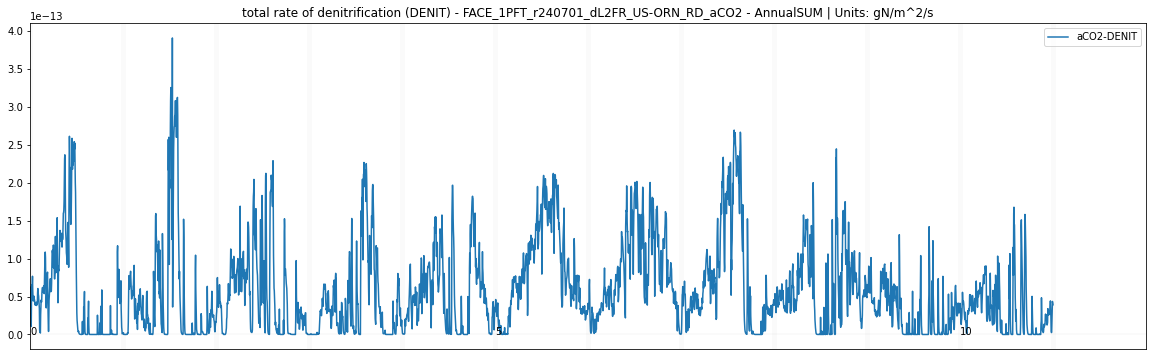

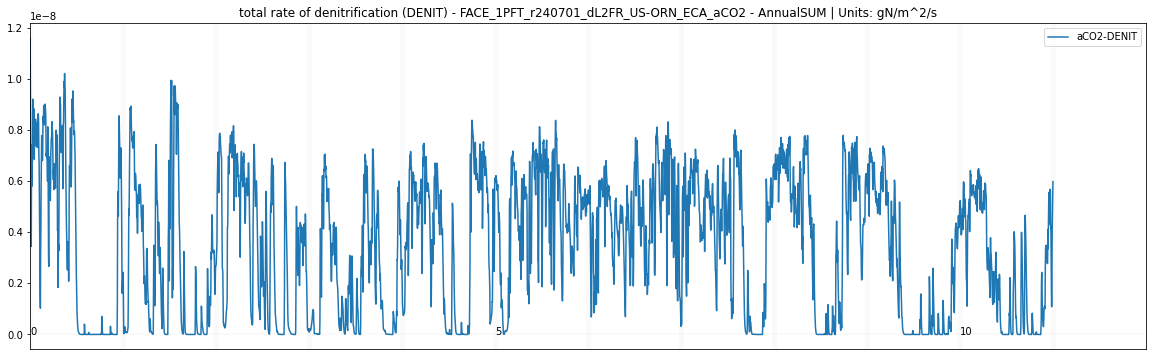

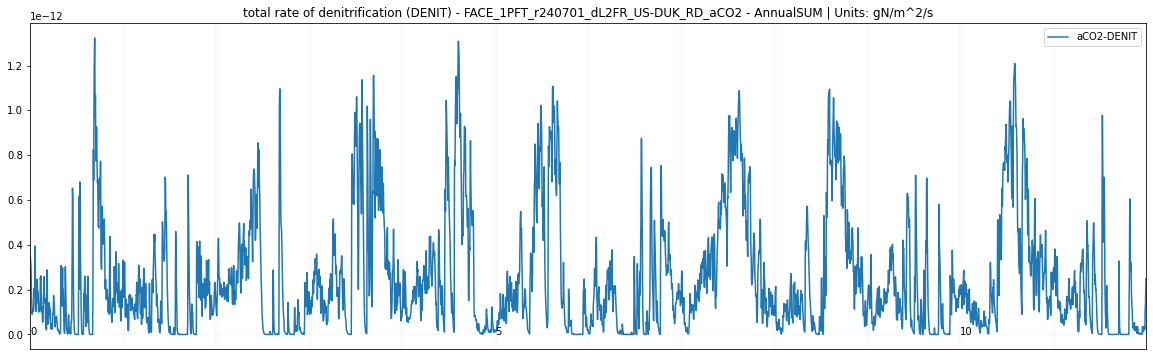

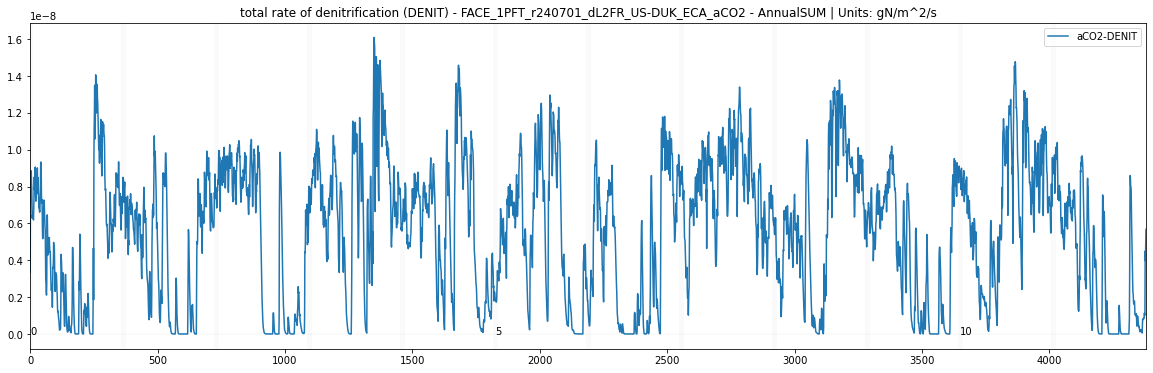

In [44]:

vars = (
        "DENIT",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    if ('COnly') in key.split("_"):
        print(f"ignoring Conly sims {key}")
        continue
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second
allocation to fine roots in kg carbon per m2 per second


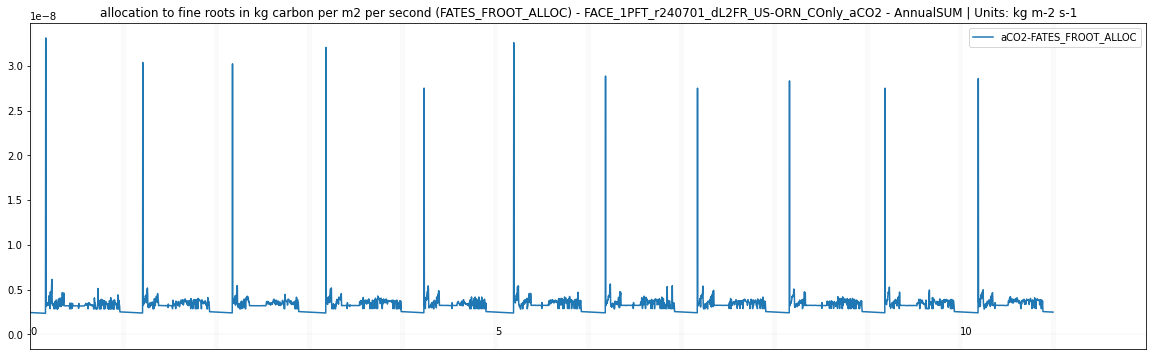

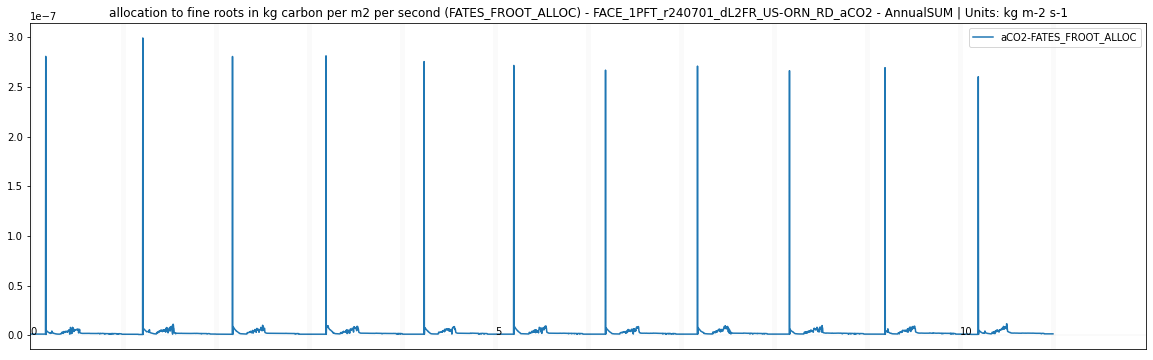

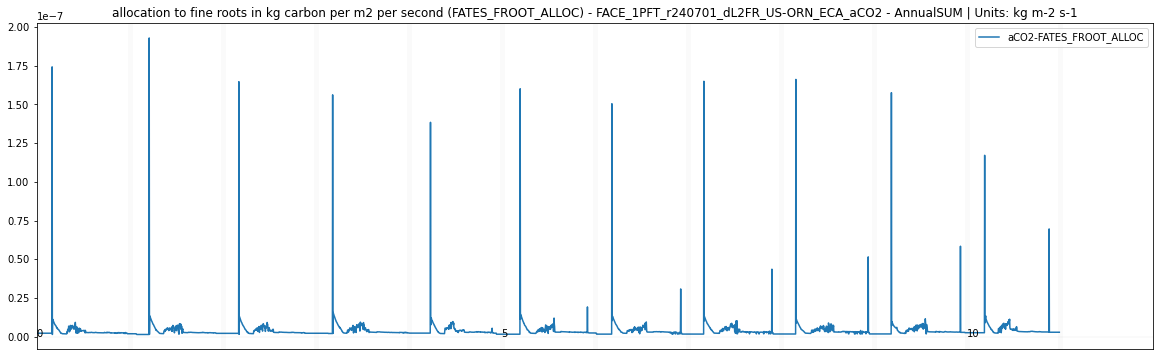

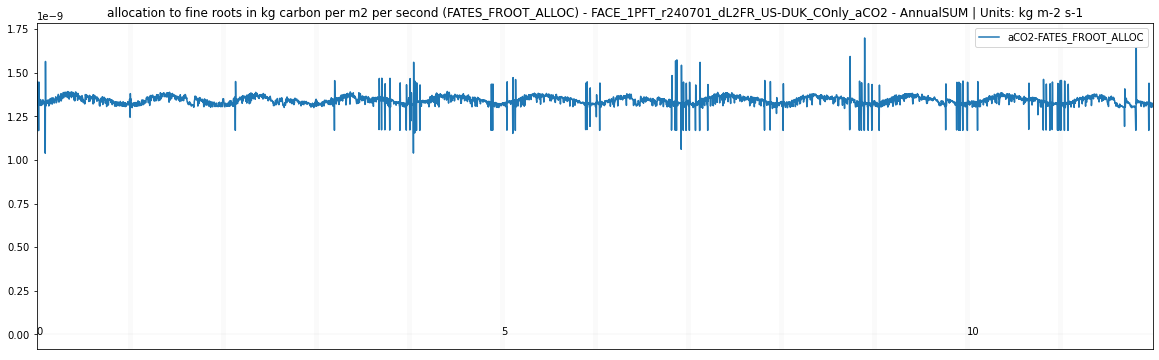

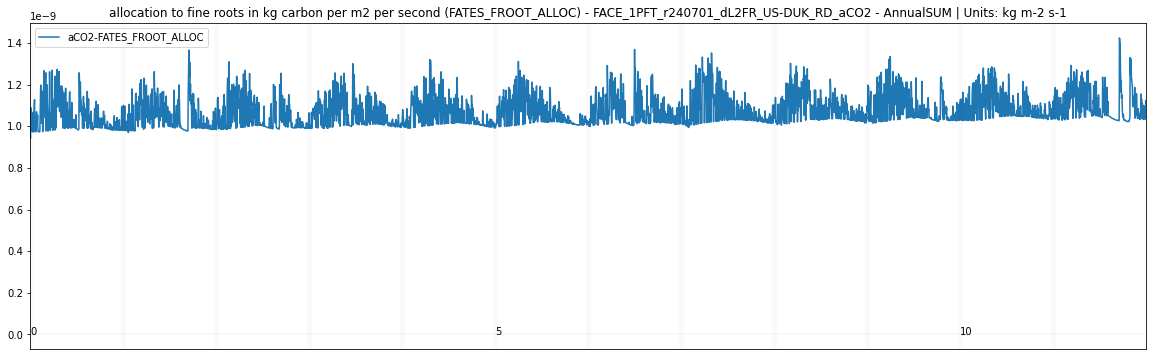

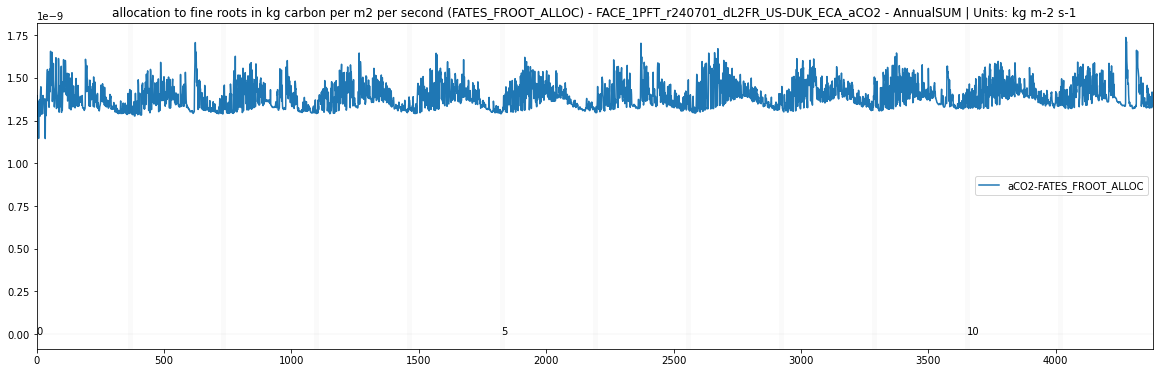

In [45]:


vars = (
        "FATES_FROOT_ALLOC",
        #"FATES_AUTORESP_USTORY"
       )

for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = f'{"-".join(key.split("_")[6:])}-{var}')
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            if max_r_years > 0:
                plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 